# This notebook creates the entire pipeline for the bikelane classifier model

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from scipy import signal as sg
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from sklearn.decomposition import PCA

## 1. Load in the data

In [34]:
def load_data(general_path):
    df_accelerometer = pd.DataFrame()
    df_gravity = pd.DataFrame()
    df_gyroscope = pd.DataFrame()
    for dir in os.listdir(general_path): # loops over each folder in the data folder
        path = general_path + "/" + dir
        data_list = os.listdir(path) # list of all the csv files of a run
        pd.concat([df_accelerometer, pd.read_csv(path + "/" + data_list[0])])
        pd.concat([df_gravity, pd.read_csv(path + "/" + data_list[3])])
        pd.concat([df_gyroscope, pd.read_csv(path + "/" + data_list[4])])

load_data("data")

PermissionError: [Errno 13] Permission denied: 'data/2_Data Yoeri/data slecht'

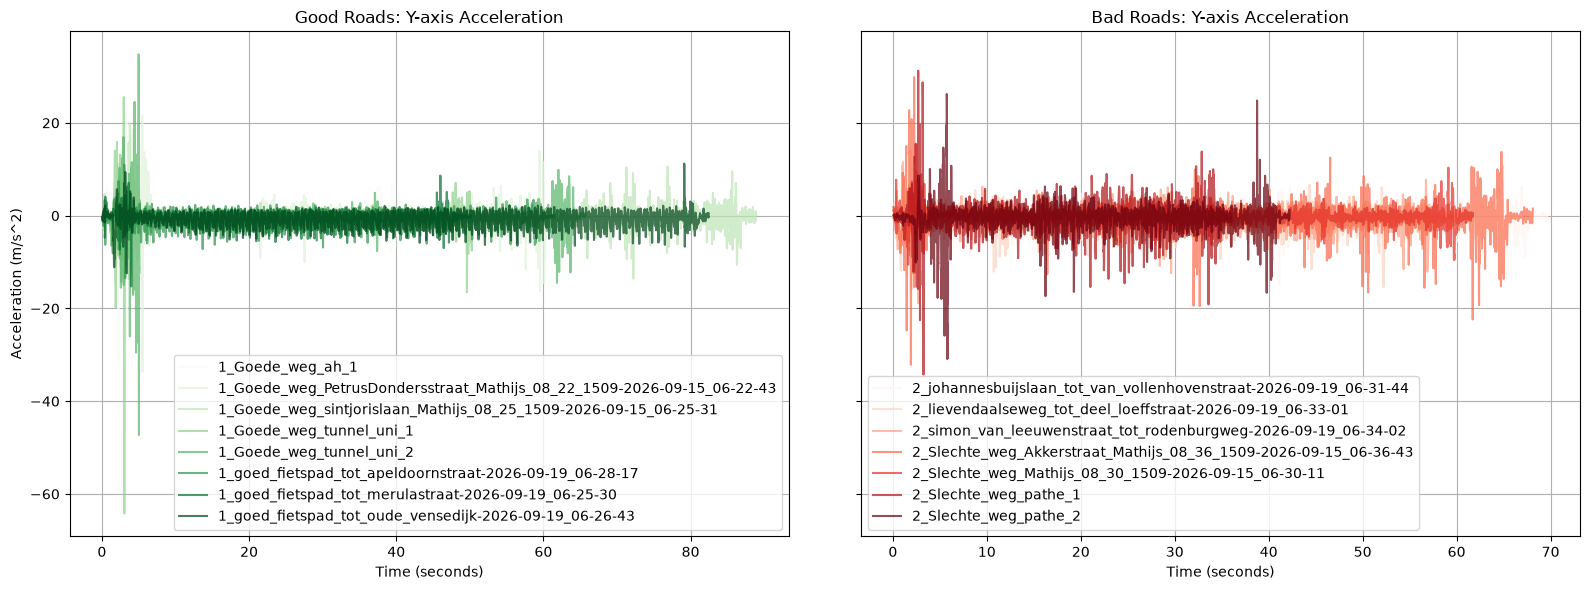

In [5]:
# Automatically discover all good roads (starting with "1") and bad roads (starting with "2")
good_paths = glob.glob("data/1_*/**/Accelerometer.csv", recursive=True)
if not good_paths:
    good_paths = glob.glob("data/1_*/Accelerometer.csv")

bad_paths = glob.glob("data/2_*/**/Accelerometer.csv", recursive=True)
if not bad_paths:
    bad_paths = glob.glob("data/2_*/Accelerometer.csv")

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Generate distinct shades of green for good roads dynamically
good_colors = plt.cm.Greens(
    [i / max(1, len(good_paths) - 1) for i in range(len(good_paths))]
)

# Plot all good road recordings
for path, color in zip(good_paths, good_colors):
    df = pd.read_csv(path)
    # Extract folder name to use as a dynamic label
    label = path.split(os.sep)[-2]
    ax1.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax1.set_title("Good Roads: Y-axis Acceleration")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Acceleration (m/s^2)")
ax1.legend()
ax1.grid(True)

# Generate distinct shades of red for bad roads dynamically
bad_colors = plt.cm.Reds(
    [i / max(1, len(bad_paths) - 1) for i in range(len(bad_paths))]
)

# Plot all bad road recordings
for path, color in zip(bad_paths, bad_colors):
    df = pd.read_csv(path)
    label = path.split(os.sep)[-2]
    ax2.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax2.set_title("Bad Roads: Y-axis Acceleration")
ax2.set_xlabel("Time (seconds)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. Trim edges of sensor data, in which the placement of the phone is documented

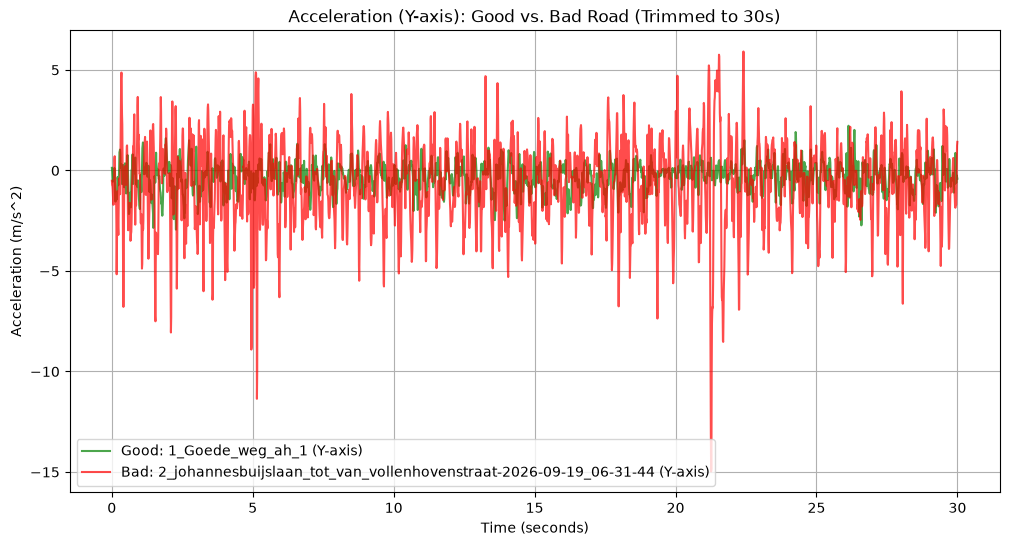

In [6]:
def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

# Process and trim all discovered good road recordings dynamically
good_roads_trimmed = {}
for path in good_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    good_roads_trimmed[key] = trim_to_30s(df)

# Process and trim all discovered bad road recordings dynamically
bad_roads_trimmed = {}
for path in bad_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    bad_roads_trimmed[key] = trim_to_30s(df)

# Plotting example: Y-axis comparison of a sample good and bad road after trimming
plt.figure(figsize=(12, 6))

if good_roads_trimmed:
    first_good_key = list(good_roads_trimmed.keys())[0]
    df_g = good_roads_trimmed[first_good_key]
    plt.plot(df_g['seconds_elapsed'], df_g['y'], label=f'Good: {first_good_key} (Y-axis)', color='green', alpha=0.7)

if bad_roads_trimmed:
    first_bad_key = list(bad_roads_trimmed.keys())[0]
    df_b = bad_roads_trimmed[first_bad_key]
    plt.plot(df_b['seconds_elapsed'], df_b['y'], label=f'Bad: {first_bad_key} (Y-axis)', color='red', alpha=0.7)

plt.title('Acceleration (Y-axis): Good vs. Bad Road (Trimmed to 30s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Preprocess the data

### 3.1 Frequency filtering of the signal

In [ ]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = sg.butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply the bandpass filter to a data array."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return sg.lfilter(b, a, data)


### 3.2 Averaging of the data

In [ ]:
def average_data(data, window_size):
    data.rolling(window=window_size, min_periods=1).mean()
    return data

### 3.6 Create windows and extract the features

In [ ]:
# 2. Windowing and Feature Extraction function (including Skewness & Kurtosis)
def create_windows_and_filter(df, window_size_sec=2.0, overlap=0.5, fs=100.0):
    """Apply sliding windows and extract statistical features from the Y-axis."""
    df_filtered = df.copy()
    # Apply bandpass filter to the Y-axis
    df_filtered['y_filtered'] = bandpass_filter(df['y'], lowcut=0.5, highcut=20.0, fs=fs)
    
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
    
    features_list = []
    window_list = []
    
    for start in range(0, len(df_filtered) - window_size_samples, step_size):
        window = df_filtered.iloc[start:start + window_size_samples]
        sig = window['y_filtered']
        
        # Extract features per window
        feat = {
            'mean': sig.mean(),
            'std': sig.std(),
            'rms': np.sqrt(np.mean(sig**2)),
            'peak_to_peak': sig.max() - sig.min(),
            'iqr': np.percentile(sig, 75) - np.percentile(sig, 25),
            'skewness': skew(sig),
            'kurtosis': kurtosis(sig)
        }
        features_list.append(feat)

        window = {
            'window_start_idx': start,
            'raw_signal': sig.values,  # stores the full array in one cell
            'mean': sig.mean(),
            'std': sig.std(),
                            }
        window_list.append(window)
        
    return pd.DataFrame(features_list),  pd.DataFrame(window_list)

# 3. Process ALL trimmed good roads and combine them into a single master dataframe
all_good_features = []
all_good_windows = []
for key, df_trimmed in good_roads_trimmed.items():
    feat_df, window_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    window_df['source'] = key
    all_good_features.append(feat_df)
    all_good_windows.append(window_df)

features_good = pd.concat(all_good_features, ignore_index=True)
windows_good = pd.concat(all_good_windows, ignore_index=True)

# 4. Process ALL trimmed bad roads and combine them into a single master dataframe
all_bad_features = []
all_bad_windows = []
for key, df_trimmed in bad_roads_trimmed.items():
    feat_df, window_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    window_df['source'] = key
    all_bad_features.append(feat_df)
    all_bad_windows.append(window_df)

features_bad = pd.concat(all_bad_features, ignore_index=True)
windows_bad = pd.concat(all_bad_windows, ignore_index=True)

# 5. Display summary results
print(f"Total feature windows generated for good roads: {len(features_good)}")
print(f"Total feature windows generated for bad roads: {len(features_bad)}")
print("\nFeature sample preview (Good roads):\n", features_good.head(3))